In [64]:
import pandas as pd
df = pd.read_csv("../data/raw_data.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [65]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [66]:
df = df.dropna(subset=['CustomerID'])

In [67]:
df = df.drop_duplicates()

In [68]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [69]:
df = df[df['Quantity'] > 0]

In [70]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [71]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [72]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
 8   Revenue      392732 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,392732.000000,392732,392732.000000,392732.000000,392732.000000
mean,13.153718,2011-07-10 19:15:24.576301568,3.125596,15287.734822,22.629195
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.390000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,181.588420,NaN,22.240725,1713.567773,311.083465


In [73]:
df.to_csv("../outputs/cleaned_data.csv", index=False)

In [74]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

<Axes: title={'center': 'Top Selling Products'}, xlabel='Description'>

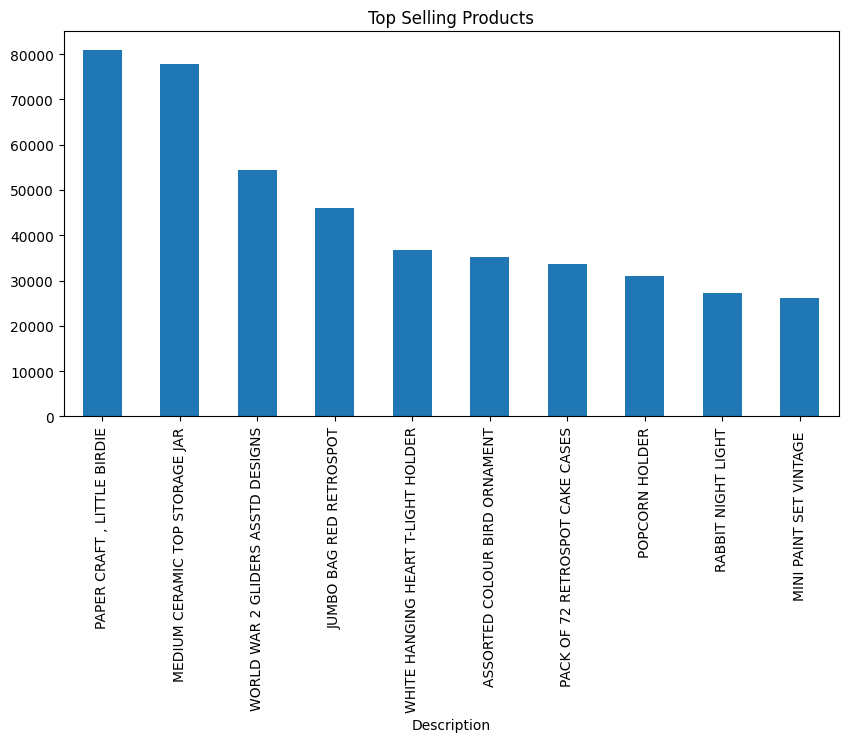

In [75]:
top_products.plot(kind='bar', figsize=(10,5), title="Top Selling Products")

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

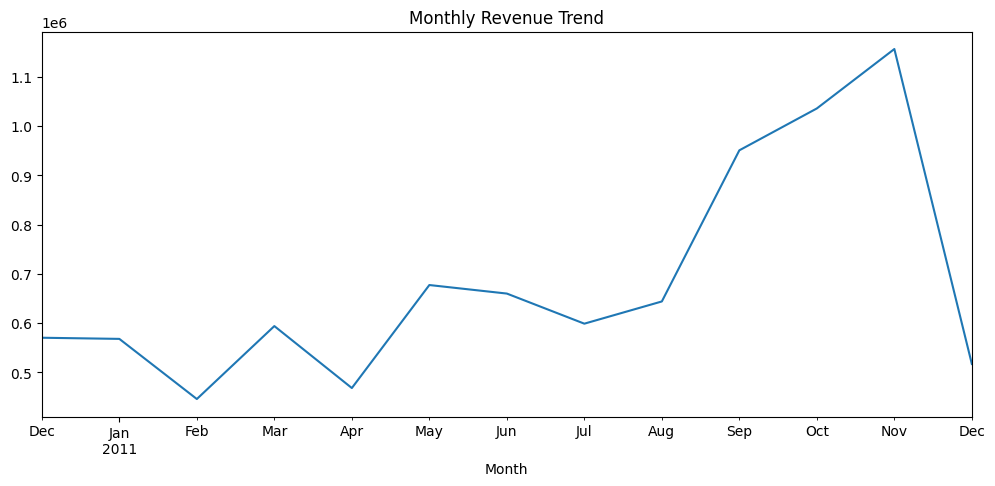

In [76]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(figsize=(12,5), title="Monthly Revenue Trend")

<Axes: title={'center': 'Top Countries by Revenue'}, xlabel='Country'>

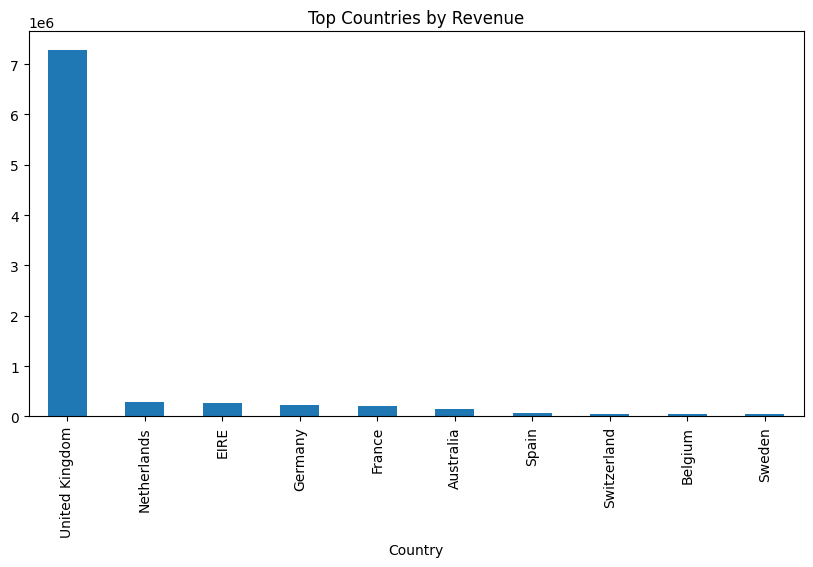

In [77]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_revenue.plot(kind='bar', figsize=(10,5), title="Top Countries by Revenue")

In [78]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [79]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = customer_orders[customer_orders > 1].count()
one_time_customers = customer_orders[customer_orders == 1].count()

print(repeat_customers, one_time_customers)

2845 1494


<Axes: title={'center': 'Revenue Distribution'}, ylabel='Frequency'>

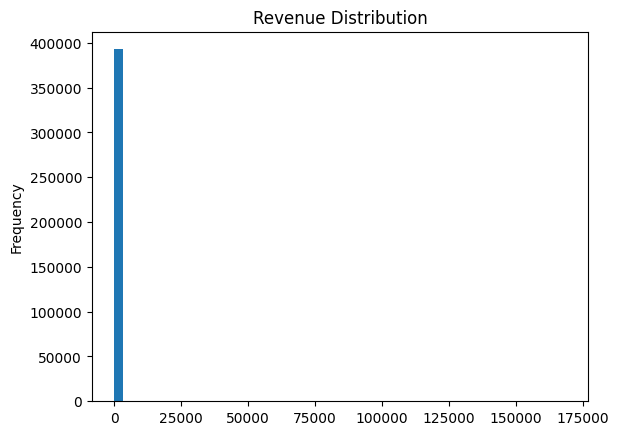

In [80]:
df['Revenue'].plot(kind='hist', bins=50, title="Revenue Distribution")

In [81]:
# Latest date in dataset
latest_date = df['InvoiceDate'].max()

# Add 1 day to avoid zero recency
reference_date = latest_date + pd.Timedelta(days=1)

In [82]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency (unique orders)
    'Revenue': 'sum'  # Monetary value
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [83]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000


In [84]:
# Divide into 4 groups (quartiles)
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [85]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [86]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'High Value'
    elif row['F_score'] == 4:
        return 'Loyal'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,7,4310.00,4,4,4,444,High Value
12348.0,75,4,1797.24,2,3,4,234,Regular
12349.0,19,1,1757.55,3,1,4,314,Regular
12350.0,310,1,334.40,1,1,2,112,At Risk


In [87]:
rfm['Segment'].value_counts()

Segment
Regular       2198
At Risk       1056
Loyal          597
High Value     488
Name: count, dtype: int64

RFM Insights

----------------------------------------------------------------------------------------------------------------

High-value customers contribute major revenue

Loyal customers purchase frequently

At-risk customers have not purchased recently

Regular customers form majority but lower value


In [88]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [89]:
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']]

In [90]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

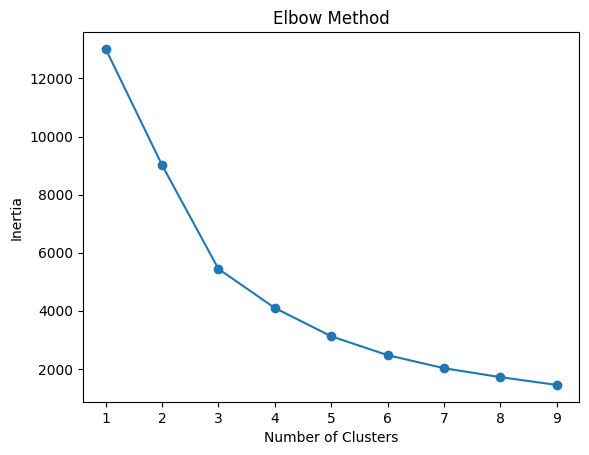

In [105]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)  # 👈 add this
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [106]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [107]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.445682,4.671928,1849.097726
1,247.106285,1.582255,629.663689
2,6.038462,66.500000,85826.078077


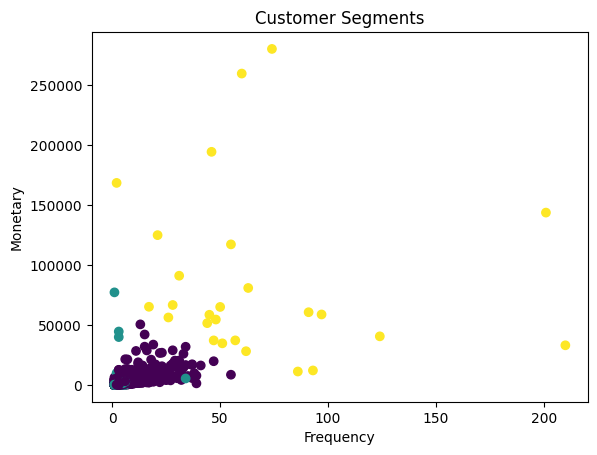

In [108]:
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()

Clustering Insights
----------------------------------------------------------------------------------------------------------

Customers are grouped into distinct segments based on behavior

One cluster shows high spending and frequent purchases

Another cluster represents low engagement customers

Clustering helps in targeted marketing strategies

In [109]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

In [110]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

In [111]:
from mlxtend.frequent_patterns import apriori, association_rules

In [114]:
basket = basket.applymap(lambda x: x > 0)

In [115]:
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
1,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
3,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.047313,0.033071,0.021364,0.451539,13.653725,1.0,0.019799,1.762987,0.972786,0.361974,0.432781,0.548771
4,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.037980,0.033233,0.022874,0.602273,18.122934,1.0,0.021612,2.430729,0.982122,0.473214,0.588601,0.645292


In [116]:
rules.sort_values('lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
75,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.029996,0.029186,0.021040,0.701439,24.033032,1.0,0.020165,3.251641,0.988027,0.551627,0.692463,0.711163
70,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.029186,0.029996,0.021040,0.720887,24.033032,1.0,0.020165,3.475313,0.987204,0.551627,0.712256,0.711163
74,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",0.037279,0.023522,0.021040,0.564399,23.994742,1.0,0.020163,2.241683,0.995433,0.529172,0.553907,0.729447
71,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.023522,0.037279,0.021040,0.894495,23.994742,1.0,0.020163,9.124923,0.981409,0.529172,0.890410,0.729447
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037279,0.029996,0.024817,0.665702,22.193256,1.0,0.023698,2.901615,0.991919,0.584498,0.655364,0.746520
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029996,0.037279,0.024817,0.827338,22.193256,1.0,0.023698,5.575760,0.984471,0.584498,0.820652,0.746520
73,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.042242,0.024817,0.021040,0.498084,20.070631,1.0,0.019992,1.942923,0.992084,0.457210,0.485311,0.672955
72,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024817,0.042242,0.021040,0.847826,20.070631,1.0,0.019992,6.293837,0.974356,0.457210,0.841114,0.672955
62,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.042242,0.029996,0.023522,0.556833,18.563760,1.0,0.022255,2.188799,0.987861,0.482835,0.543129,0.670503
63,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.029996,0.042242,0.023522,0.784173,18.563760,1.0,0.022255,4.437611,0.975389,0.482835,0.774654,0.670503


In [117]:
product_matrix = basket.T

In [118]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(product_matrix)

In [119]:
import pandas as pd

similarity_df = pd.DataFrame(similarity, index=product_matrix.index, columns=product_matrix.index)

In [120]:
similarity_df['WHITE HANGING HEART T-LIGHT HOLDER'].sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    1.000000
RED HANGING HEART T-LIGHT HOLDER      0.393308
CANDLEHOLDER PINK HANGING HEART       0.307702
WOODEN PICTURE FRAME WHITE FINISH     0.234399
HEART OF WICKER LARGE                 0.230801
WOODEN FRAME ANTIQUE WHITE            0.201691
HEART OF WICKER SMALL                 0.194729
NATURAL SLATE HEART CHALKBOARD        0.191951
ZINC METAL HEART DECORATION           0.179640
HOME BUILDING BLOCK WORD              0.179087
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

Recommendation Insights
------------------------------------------------------------------------------------------------------

Certain products are frequently bought together

Strong associations can be used for cross-selling

Similarity-based recommendations improve user experience
